# Decision Trees for Highly Cited Research Papers

This notebook predicts whether a research paper is highly cited instead of whether a song is popular.


## Setup


In [1]:
import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy.sparse import csr_matrix, hstack
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree


## Load Research Paper Data


In [2]:
# Load the joined OpenAlex + Semantic Scholar data used in the K-Means notebook.
DB_PATH = Path("papers.db")
if not DB_PATH.exists():
    DB_PATH = Path("../papers.db")

JOINED_QUERY = """
SELECT
    o.openalex_id,
    o.doi,
    o.doi_normalized,
    o.title,
    o.publication_year,
    o.cited_by_count,
    o.author_count,
    o.primary_topic,
    o.primary_subfield,
    o.primary_field,
    o.primary_domain,
    s.abstract_text,
    s.abstract_tfidf_vector
FROM openalex_papers AS o
JOIN semanticscholar_papers AS s
    ON o.doi_normalized = s.doi_normalized
WHERE s.abstract_tfidf_vector IS NOT NULL
  AND TRIM(s.abstract_tfidf_vector) <> ''
  AND o.cited_by_count IS NOT NULL
"""

with sqlite3.connect(DB_PATH) as conn:
    df = pl.read_database(query=JOINED_QUERY, connection=conn)

print(f"Joined rows with abstract vectors and citation counts: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()


Joined rows with abstract vectors and citation counts: 20089
Columns: 13


openalex_id,doi,doi_normalized,title,publication_year,cited_by_count,author_count,primary_topic,primary_subfield,primary_field,primary_domain,abstract_text,abstract_tfidf_vector
str,str,str,str,i64,i64,i64,str,str,str,str,str,str
"""https://openalex.org/W43627070…","""https://doi.org/10.1016/j.patc…","""10.1016/j.patcog.2026.113208""","""RFAConv: Receptive-field atten…",2026,86,7,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…","""Computer Science""","""Physical Sciences""","""In the realm of deep learning,…","""{""dimension"": 2000, ""indices"":…"
"""https://openalex.org/W71290307…","""https://doi.org/10.1145/379651…","""10.1145/3796519""","""Model Context Protocol (MCP): …",2026,22,4,"""Security and Verification in C…","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""The Model Context Protocol (MC…","""{""dimension"": 2000, ""indices"":…"
"""https://openalex.org/W44007028…","""https://doi.org/10.1109/tnnls.…","""10.1109/tnnls.2025.3646122""","""Graph Transformers: A Survey""",2026,16,7,"""Advanced Graph Neural Networks""","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""Graph transformers are a recen…","""{""dimension"": 2000, ""indices"":…"
"""https://openalex.org/W43969140…","""https://doi.org/10.1007/s11263…","""10.1007/s11263-025-02646-6""","""Deep Learning-Based Object Pos…",2026,14,10,"""Hand Gesture Recognition Syste…","""Human-Computer Interaction""","""Computer Science""","""Physical Sciences""","""Object pose estimation is a fu…","""{""dimension"": 2000, ""indices"":…"
"""https://openalex.org/W44043502…","""https://doi.org/10.1038/s41567…","""10.1038/s41567-025-03144-9""","""Dynamical simulations of many-…",2026,9,19,"""Neural Networks and Reservoir …","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""Quantum circuits with local un…","""{""dimension"": 2000, ""indices"":…"


## Binarize Citation Popularity

The homework used `binarize_popularity` to mark songs as popular. Here, the same function name creates a `highly_cited` boolean label from `cited_by_count`.


In [3]:
def binarize_popularity(df: pl.DataFrame, threshold: int = 1) -> pl.DataFrame:
    """
    Add a 'highly_cited' boolean column indicating whether a paper is highly cited.

    Requirements:
    - Add a new column 'highly_cited' (boolean):
        - True if cited_by_count >= threshold
        - False if cited_by_count < threshold
    - Do not modify any existing columns

    Args:
        df: Polars DataFrame with a 'cited_by_count' column
        threshold: citation-count cutoff

    Returns:
        DataFrame with added 'highly_cited' boolean column

    Example:
        >>> sample = pl.DataFrame({'cited_by_count': [0, 1, 10]})
        >>> result = binarize_popularity(sample, threshold=1)
        >>> result['highly_cited'].to_list()
        [False, True, True]
    """
    return df.with_columns(
        (pl.col("cited_by_count").fill_null(0) >= threshold).alias("highly_cited")
    )


# Quick sanity check before using the helper on the full dataset.
sample = pl.DataFrame({"cited_by_count": [0, 1, 10]})
binarize_popularity(sample, threshold=1)["highly_cited"].to_list()


[False, True, True]

In [4]:
# The citation distribution is very skewed, so use the 95th percentile as a data-aware cutoff.
# For this dataset, that cutoff is 1 citation. Raise this manually for a stricter definition.
CITATION_THRESHOLD = max(
    1,
    int(df.select(pl.col("cited_by_count").quantile(0.95, interpolation="nearest")).item()),
)

df_labeled = binarize_popularity(df, threshold=CITATION_THRESHOLD)

label_counts = (
    df_labeled
    .group_by("highly_cited")
    .len()
    .with_columns((pl.col("len") / df_labeled.height).alias("fraction"))
    .sort("highly_cited")
)

print(f"Highly cited threshold: cited_by_count >= {CITATION_THRESHOLD}")
label_counts


Highly cited threshold: cited_by_count >= 1


highly_cited,len,fraction
bool,u32,f64
false,18947,0.943153
true,1142,0.056847


## Prepare Features

`cited_by_count` is the target source, so it is intentionally excluded from the feature matrix. The notebook reuses the stored abstract TF-IDF vectors from `papers.db` instead of fitting a new text vectorizer here.


### Define split settings and shared feature columns


In [5]:
NUMERIC_FEATURES = ["publication_year", "log_author_count"]
CATEGORICAL_FEATURES = ["primary_topic", "primary_subfield", "primary_field", "primary_domain"]
SPLIT_RANDOM_STATE = 42
TEST_SIZE = 0.20
VALIDATION_SHARE_OF_TRAIN_VAL = 0.25

def summarize_split(split_name: str, labels: np.ndarray) -> dict:
    """Return a compact summary row for one label split."""
    return {
        "split": split_name,
        "rows": int(labels.shape[0]),
        "positives": int(labels.sum()),
        "positive_rate": round(float(labels.mean()), 4),
    }


### Create train, validation, and test splits


In [6]:
# Split indices first so every feature block uses the same row partitions.
# The test set stays untouched until the very end of the notebook.
y_binary = df_labeled["highly_cited"].to_numpy().astype(int)
all_indices = np.arange(df_labeled.height)

train_val_indices, test_indices = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    random_state=SPLIT_RANDOM_STATE,
    stratify=y_binary,
)

y_train_val = y_binary[train_val_indices]
train_indices, val_indices = train_test_split(
    train_val_indices,
    test_size=VALIDATION_SHARE_OF_TRAIN_VAL,
    random_state=SPLIT_RANDOM_STATE,
    stratify=y_train_val,
)

df_train = df_labeled[train_indices]
df_val = df_labeled[val_indices]
df_train_val = df_labeled[train_val_indices]
df_test = df_labeled[test_indices]

y_train = y_binary[train_indices]
y_val = y_binary[val_indices]
y_train_val = y_binary[train_val_indices]
y_test = y_binary[test_indices]

split_summary = pl.DataFrame([
    summarize_split("train", y_train),
    summarize_split("validation", y_val),
    summarize_split("test", y_test),
])
split_summary


split,rows,positives,positive_rate
str,i64,i64,f64
"""train""",12053,685,0.0568
"""validation""",4018,229,0.057
"""test""",4018,228,0.0567


### Build the numeric feature block


In [7]:
def build_numeric_matrix(papers_df: pl.DataFrame) -> np.ndarray:
    """Build the numeric feature block without using full-dataset statistics."""
    return papers_df.select([
        # The scraped papers are all from the same year, so publication_year is constant here.
        pl.lit(2026.0).alias("publication_year"),
        # Log-scaling author counts keeps extreme values from dominating the tree.
        pl.col("author_count")
          .fill_null(0)
          .clip(lower_bound=0)
          .log1p()
          .cast(pl.Float64)
          .alias("log_author_count"),
    ]).to_numpy()


In [8]:
numeric_train = build_numeric_matrix(df_train)
numeric_val = build_numeric_matrix(df_val)
numeric_train_val = build_numeric_matrix(df_train_val)
numeric_test = build_numeric_matrix(df_test)

numeric_summary = pl.DataFrame([
    {"split": "train", "shape": str(numeric_train.shape)},
    {"split": "validation", "shape": str(numeric_val.shape)},
    {"split": "test", "shape": str(numeric_test.shape)},
])
numeric_summary


split,shape
str,str
"""train""","""(12053, 2)"""
"""validation""","""(4018, 2)"""
"""test""","""(4018, 2)"""


### Build the categorical feature block


In [9]:
def build_categorical_values(papers_df: pl.DataFrame) -> np.ndarray:
    """Return the raw categorical values in the column order expected by the encoder."""
    return papers_df.select([
        pl.col(column).fill_null("Unknown") for column in CATEGORICAL_FEATURES
    ]).to_numpy()

def fit_categorical_encoder(papers_df: pl.DataFrame) -> OneHotEncoder:
    """Fit the categorical encoder on one reference split."""
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=20,
        sparse_output=True,
    )
    encoder.fit(build_categorical_values(papers_df))
    return encoder

def transform_categorical_matrix(encoder: OneHotEncoder, papers_df: pl.DataFrame):
    """Transform one split with an already-fitted encoder."""
    return encoder.transform(build_categorical_values(papers_df))


In [10]:
# Fit on the training split only, then reuse the same encoder for validation and test.
categorical_encoder = fit_categorical_encoder(df_train)
categorical_train = transform_categorical_matrix(categorical_encoder, df_train)
categorical_val = transform_categorical_matrix(categorical_encoder, df_val)
categorical_test = transform_categorical_matrix(categorical_encoder, df_test)

categorical_summary = pl.DataFrame([
    {"split": "train", "shape": str(categorical_train.shape)},
    {"split": "validation", "shape": str(categorical_val.shape)},
    {"split": "test", "shape": str(categorical_test.shape)},
])
categorical_summary


split,shape
str,str
"""train""","""(12053, 159)"""
"""validation""","""(4018, 159)"""
"""test""","""(4018, 159)"""


### Build the stored abstract TF-IDF block


In [11]:
def stored_tfidf_vectors_to_csr(vector_jsons: list[str]) -> csr_matrix:
    """Convert stored TF-IDF JSON vectors from the database into a CSR matrix."""
    data = []
    indices = []
    indptr = [0]
    dimension = None

    for vector_json in vector_jsons:
        vector = json.loads(vector_json)
        vector_dimension = int(vector["dimension"])

        if dimension is None:
            dimension = vector_dimension
        elif dimension != vector_dimension:
            raise ValueError("Stored abstract TF-IDF vectors have inconsistent dimensions")

        indices.extend(vector["indices"])
        data.extend(vector["values"])
        indptr.append(len(indices))

    return csr_matrix((data, indices, indptr), shape=(len(vector_jsons), dimension))


In [12]:
# The stored vectors are already aligned with df_labeled, so we can split by row index.
abstract_matrix = stored_tfidf_vectors_to_csr(df_labeled["abstract_tfidf_vector"].to_list())
abstract_train = abstract_matrix[train_indices]
abstract_val = abstract_matrix[val_indices]
abstract_train_val = abstract_matrix[train_val_indices]
abstract_test = abstract_matrix[test_indices]

# The saved vectors do not include the original vocabulary, so use position-based names.
abstract_feature_names = [
    f"abstract_tfidf_{i}" for i in range(abstract_matrix.shape[1])
]

text_summary = pl.DataFrame([
    {"split": "train", "shape": str(abstract_train.shape)},
    {"split": "validation", "shape": str(abstract_val.shape)},
    {"split": "test", "shape": str(abstract_test.shape)},
])
text_summary


split,shape
str,str
"""train""","""(12053, 2000)"""
"""validation""","""(4018, 2000)"""
"""test""","""(4018, 2000)"""


### Assemble the full feature matrices


In [13]:
def assemble_feature_matrix(
    numeric_block: np.ndarray,
    categorical_block,
    text_block: csr_matrix,
) -> csr_matrix:
    """Stack the numeric, categorical, and text blocks into one sparse matrix."""
    return hstack([
        csr_matrix(numeric_block),
        categorical_block,
        text_block,
    ], format="csr")

def build_feature_names(encoder: OneHotEncoder) -> list[str]:
    """Return column names in the same order used to assemble the feature matrix."""
    return (
        NUMERIC_FEATURES
        + encoder.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
        + abstract_feature_names
    )


In [14]:
X_train = assemble_feature_matrix(numeric_train, categorical_train, abstract_train)
X_val = assemble_feature_matrix(numeric_val, categorical_val, abstract_val)
X_test = assemble_feature_matrix(numeric_test, categorical_test, abstract_test)
feature_names = build_feature_names(categorical_encoder)

feature_summary = pl.DataFrame([
    {"split": "train", "shape": str(X_train.shape)},
    {"split": "validation", "shape": str(X_val.shape)},
    {"split": "test", "shape": str(X_test.shape)},
])
feature_summary


split,shape
str,str
"""train""","""(12053, 2161)"""
"""validation""","""(4018, 2161)"""
"""test""","""(4018, 2161)"""


In [15]:
print(f"Number of positive labels: {int(y_binary.sum())}")
print(f"Number of feature names: {len(feature_names)}")
split_summary


Number of positive labels: 1142
Number of feature names: 2161


split,rows,positives,positive_rate
str,i64,i64,f64
"""train""",12053,685,0.0568
"""validation""",4018,229,0.057
"""test""",4018,228,0.0567


## Tune the Tree Depth on Validation Data

The tree is trained on `train`, compared on `validation`, and only evaluated on `test` after the best depth is chosen.


In [16]:
CANDIDATE_DEPTHS = [2, 3, 5, 8, 12, None]

def depth_label(depth: int | None) -> str:
    """Format depth values so tables read cleanly."""
    return str(depth) if depth is not None else "unlimited"

def train_decision_tree(
    X_train,
    y_train: np.ndarray,
    max_depth: int | None = 5,
    random_state: int = 42,
    class_weight: str | None = "balanced",
    min_samples_leaf: int = 200,
    min_samples_split: int = 400,
):
    """Train and return a regularized decision tree classifier."""
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=random_state,
        class_weight=class_weight,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
    )
    model.fit(X_train, y_train)
    return model

def evaluate_classifier(model, X_eval, y_eval: np.ndarray) -> dict:
    """Return standard binary-classification metrics for one evaluation split."""
    y_pred = model.predict(X_eval)
    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred, labels=[0, 1]).ravel()

    return {
        "accuracy": float(accuracy_score(y_eval, y_pred)),
        "precision": float(precision_score(y_eval, y_pred, zero_division=0)),
        "recall": float(recall_score(y_eval, y_pred, zero_division=0)),
        "f1": float(f1_score(y_eval, y_pred, zero_division=0)),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    }


In [17]:
def evaluate_candidate_depths(candidate_depths: list[int | None]) -> pl.DataFrame:
    """Train one model per depth and collect validation metrics in a table."""
    rows = []

    for depth in candidate_depths:
        model = train_decision_tree(X_train, y_train, max_depth=depth)
        metrics = evaluate_classifier(model, X_val, y_val)
        rows.append({
            "max_depth": depth_label(depth),
            "actual_depth": int(model.tree_.max_depth),
            "leaves": int(model.tree_.n_leaves),
            "min_samples_leaf": int(model.min_samples_leaf),
            "min_samples_split": int(model.min_samples_split),
            "train_accuracy": round(float(model.score(X_train, y_train)), 3),
            "validation_accuracy": round(metrics["accuracy"], 3),
            "precision": round(metrics["precision"], 3),
            "recall": round(metrics["recall"], 3),
            "f1": round(metrics["f1"], 3),
            "false_positives": metrics["false_positives"],
            "false_negatives": metrics["false_negatives"],
        })

    return pl.DataFrame(rows)

depth_results_df = evaluate_candidate_depths(CANDIDATE_DEPTHS)
depth_results_df


max_depth,actual_depth,leaves,min_samples_leaf,min_samples_split,train_accuracy,validation_accuracy,precision,recall,f1,false_positives,false_negatives
str,i64,i64,i64,i64,f64,f64,f64,f64,f64,i64,i64
"""2""",2,4,200,400,0.804,0.799,0.099,0.31,0.15,648,158
"""3""",3,7,200,400,0.801,0.792,0.092,0.297,0.14,673,161
"""5""",5,13,200,400,0.801,0.792,0.092,0.297,0.14,673,161
"""8""",8,18,200,400,0.781,0.769,0.081,0.297,0.128,767,161
"""12""",12,24,200,400,0.73,0.715,0.077,0.367,0.128,1001,145
"""unlimited""",27,47,200,400,0.575,0.544,0.064,0.511,0.113,1719,112


In [18]:
# Choose the model with the best validation F1.
# Break ties with validation accuracy, then prefer the shallower tree.
best_result = max(
    depth_results_df.to_dicts(),
    key=lambda row: (row["f1"], row["validation_accuracy"], -row["actual_depth"]),
)
best_depth = None if best_result["max_depth"] == "unlimited" else int(best_result["max_depth"])

print(f"Selected max_depth from validation F1: {best_result['max_depth']}")
print(f"Validation F1: {best_result['f1']:.3f}")
best_result


Selected max_depth from validation F1: 2
Validation F1: 0.150


{'max_depth': '2',
 'actual_depth': 2,
 'leaves': 4,
 'min_samples_leaf': 200,
 'min_samples_split': 400,
 'train_accuracy': 0.804,
 'validation_accuracy': 0.799,
 'precision': 0.099,
 'recall': 0.31,
 'f1': 0.15,
 'false_positives': 648,
 'false_negatives': 158}

## Fit the Final Model and Evaluate on Test Data


In [19]:
# Refit the categorical encoder on train+validation so the final model uses
# as much non-test data as possible before the one-time test evaluation.
categorical_encoder_final = fit_categorical_encoder(df_train_val)
categorical_train_val = transform_categorical_matrix(categorical_encoder_final, df_train_val)
categorical_test_final = transform_categorical_matrix(categorical_encoder_final, df_test)

X_train_val = assemble_feature_matrix(
    numeric_train_val,
    categorical_train_val,
    abstract_train_val,
)
X_test_final = assemble_feature_matrix(
    numeric_test,
    categorical_test_final,
    abstract_test,
)
final_feature_names = build_feature_names(categorical_encoder_final)


In [20]:
dt_model = train_decision_tree(X_train_val, y_train_val, max_depth=best_depth)
dt_metrics = evaluate_classifier(dt_model, X_test_final, y_test)

print(f"Selected max_depth: {best_result['max_depth']}")
print(f"Tree depth: {dt_model.tree_.max_depth}")
print(f"Number of leaves: {dt_model.tree_.n_leaves}")
dt_metrics


Selected max_depth: 2
Tree depth: 2
Number of leaves: 4


{'accuracy': 0.7877053260328521,
 'precision': 0.07598371777476255,
 'recall': 0.24561403508771928,
 'f1': 0.11606217616580311,
 'true_negatives': 3109,
 'false_positives': 681,
 'false_negatives': 172,
 'true_positives': 56}

## Visualize the Decision Tree


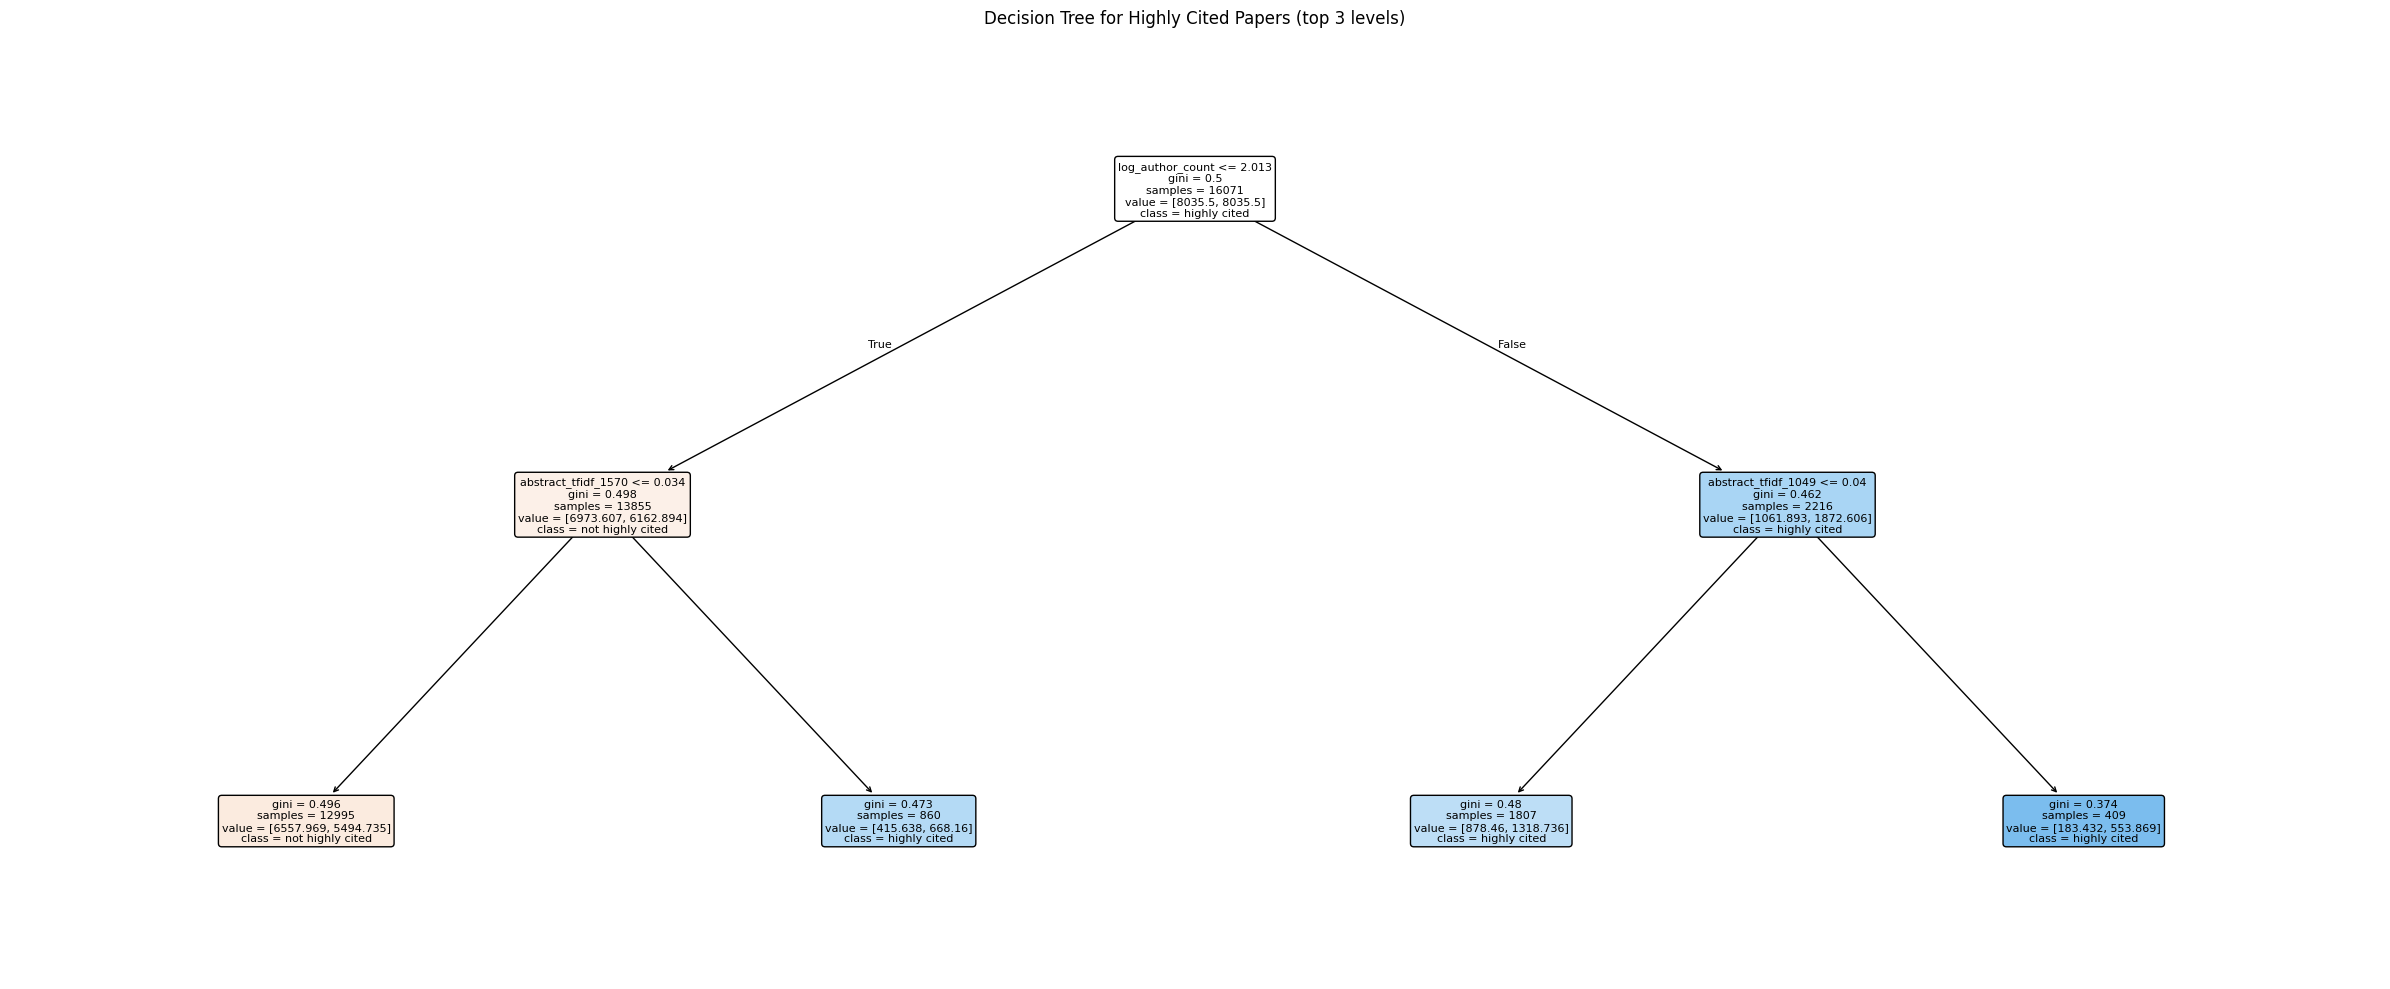

In [21]:
# Plot only the top few levels so the learned rules remain readable.
plt.figure(figsize=(24, 10))
plot_tree(
    dt_model,
    feature_names=final_feature_names,
    class_names=["not highly cited", "highly cited"],
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Decision Tree for Highly Cited Papers (top 3 levels)")
plt.tight_layout()
plt.show()


### Comments on Performance

- Adding `min_samples_leaf=200` and `min_samples_split=400` regularizes the tree by preventing splits that only explain a tiny handful of papers.
- The target is very imbalanced: only a small share of joined papers are labeled `highly_cited`, so accuracy is not very informative by itself.
- Compared with an unregularized tree, the regularized tree usually makes fewer false-positive predictions and has fewer leaves, which makes it easier to interpret.
- The improvement is modest: regularization makes the classifier less chaotic, but precision and F1 are still low because citation prediction is noisy and the positive class is rare.
- For this dataset, the best tree is not necessarily the one with the highest accuracy. F1, precision, and recall are more useful because the positive class is rare.
